In [60]:
import numpy as np
import pandas as pd

In [61]:
df=pd.read_csv("user_level_ai_adoption.csv")
df.head()

,User_ID,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Adoption_Date
0,USR-690F519F,Software Development,Software Engineer,Europe,13,ChatGPT (OpenAI),10640,2,19.3,2023-02-28
1,USR-72A07ABB,Software Development,Software Engineer,North America,9,Claude (Anthropic),8535,1,5.0,2023-08-17
2,USR-CBCEAA19,Finance,Accountant,Asia-Pacific,21,Claude (Anthropic),9585,1,13.4,2023-11-02
3,USR-03B7DC34,Healthcare,Clinical Admin,North America,20,Perplexity,7094,2,9.9,2025-06-06
4,USR-CA8308D1,Marketing,Social Media Manager,Asia-Pacific,14,ChatGPT (OpenAI),9277,1,12.8,2023-04-03


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,ExtraTreesRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [63]:
df.shape

(15000, 10)

In [64]:
df.nunique()


,0
User_ID,15000
Industry,6
Job_Role,22
Location,5
Experience_Years,25
Primary_AI_Tool,7
Daily_Token_Usage,10083
Tasks_Automated_Per_Week,12
Productivity_Gain_Percent,666
Adoption_Date,1940


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    15000 non-null  object 
 1   Industry                   15000 non-null  object 
 2   Job_Role                   15000 non-null  object 
 3   Location                   15000 non-null  object 
 4   Experience_Years           15000 non-null  int64  
 5   Primary_AI_Tool            15000 non-null  object 
 6   Daily_Token_Usage          15000 non-null  int64  
 7   Tasks_Automated_Per_Week   15000 non-null  int64  
 8   Productivity_Gain_Percent  15000 non-null  float64
 9   Adoption_Date              15000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.1+ MB


In [66]:
df.isnull().sum()


,0
User_ID,0
Industry,0
Job_Role,0
Location,0
Experience_Years,0
Primary_AI_Tool,0
Daily_Token_Usage,0
Tasks_Automated_Per_Week,0
Productivity_Gain_Percent,0
Adoption_Date,0


In [67]:
df.duplicated().sum()


np.int64(0)

In [68]:
int_col=['Experience_Years','Daily_Token_Usage','Tasks_Automated_Per_Week']
outlier={}

for c in int_col:
    q1=df[c].quantile(0.25)
    q3=df[c].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    #Detect Outliers (Boolean Mask)

    rng=(df[c]<lower)|(df[c]>upper)
#Count Outliers
    outlier[c]=int(rng.sum())

    ## handling outlier with cap
    df[c]=df[c].clip(lower,upper)

outlier
#Shows dictionary of outlier counts

{'Experience_Years': 0,
 'Daily_Token_Usage': 785,
 'Tasks_Automated_Per_Week': 186}

In [69]:
# droping user id column¶
df=df.drop(columns=['User_ID'])



In [71]:
#covert Adoption_Date to datetime
df['Adoption_Date']=pd.to_datetime(df['Adoption_Date'],errors="coerce")
df['year']=df['Adoption_Date'].dt.year
df['month']=df['Adoption_Date'].dt.month
df['day']=df['Adoption_Date'].dt.day
df['dayofweek']=df['Adoption_Date'].dt.dayofweek
df=df.drop(columns=['Adoption_Date'])

In [72]:
df.head()

,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,year,month,day,dayofweek
0,Software Development,Software Engineer,Europe,13,ChatGPT (OpenAI),10640.0,2,19.3,2023,2,28,1
1,Software Development,Software Engineer,North America,9,Claude (Anthropic),8535.0,1,5.0,2023,8,17,3
2,Finance,Accountant,Asia-Pacific,21,Claude (Anthropic),9585.0,1,13.4,2023,11,2,3
3,Healthcare,Clinical Admin,North America,20,Perplexity,7094.0,2,9.9,2025,6,6,4
4,Marketing,Social Media Manager,Asia-Pacific,14,ChatGPT (OpenAI),9277.0,1,12.8,2023,4,3,0


EDA
DISTRIBUTION OF TARGET COLUMN


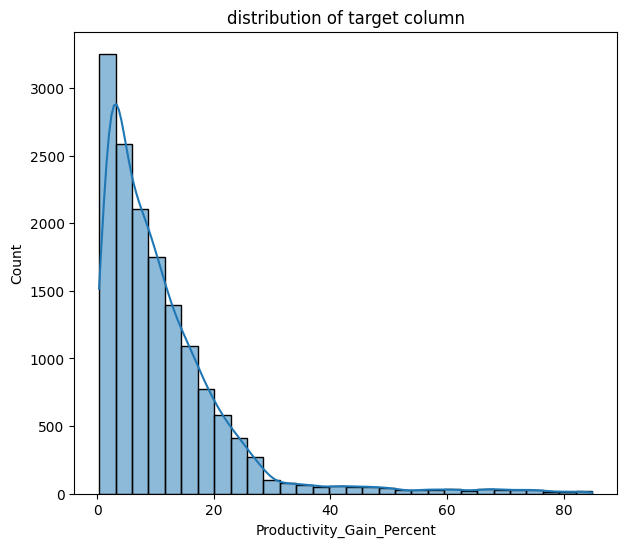

In [73]:
trgt='Productivity_Gain_Percent'
plt.figure(figsize=(7,6))
sns.histplot(df[trgt].dropna(),kde=True,bins=30)
plt.title("distribution of target column")
plt.show()

# RELATION BETWEEN TARGET VS ALL COLUMNS

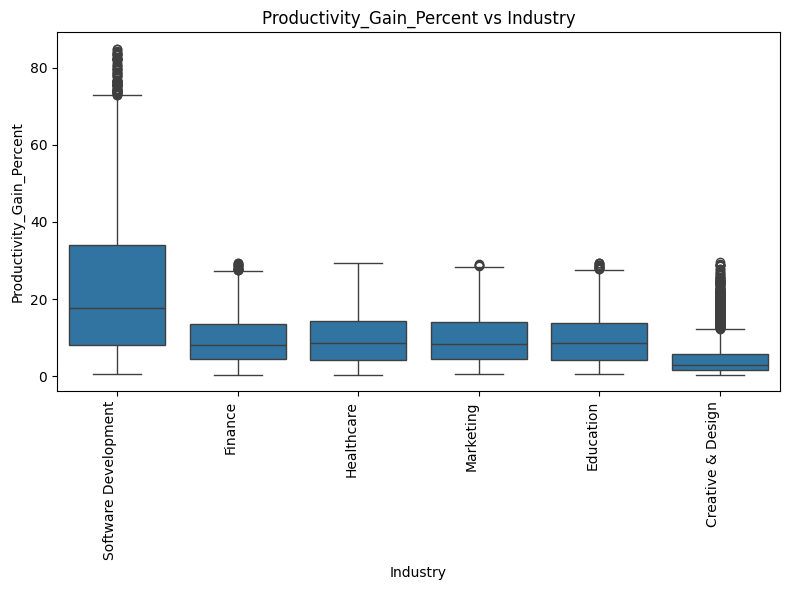

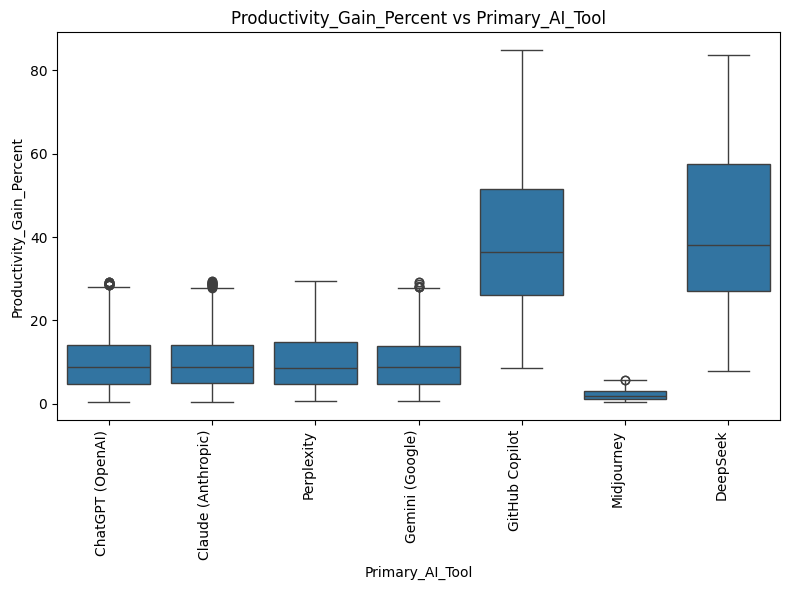

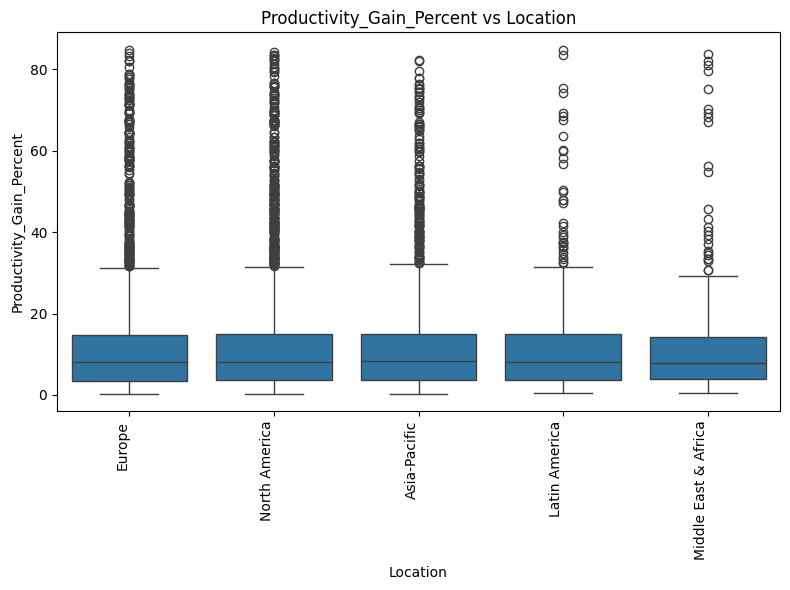

In [74]:
trgt='Productivity_Gain_Percent'
cols=['Industry','Primary_AI_Tool' , 'Location']
for c in cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[c],y=df[trgt])
    plt.title(f"{trgt} vs {c}")
    plt.xticks(rotation=90,ha="right")
    plt.tight_layout()
    plt.show()
    print("\n")

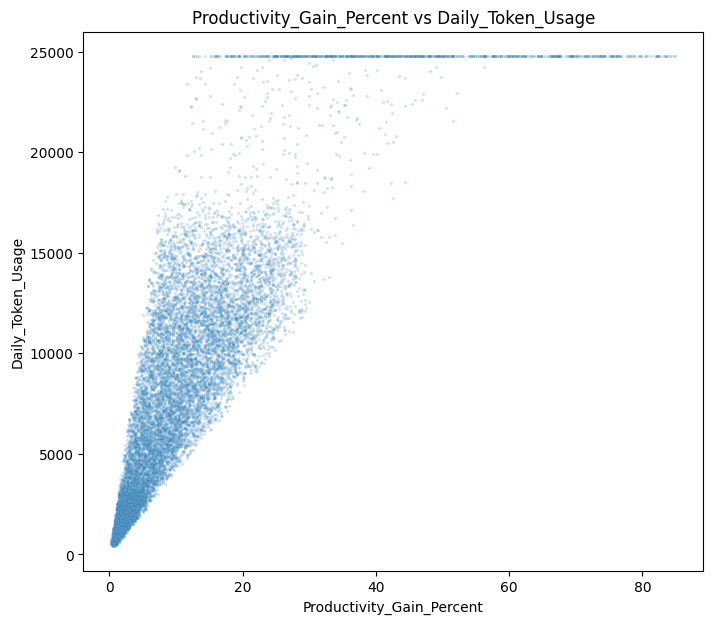

In [75]:
plt.figure(figsize=(8,7))
sns.scatterplot(data=df,x=trgt,y='Daily_Token_Usage',s=5,alpha=0.2)
plt.title(f"{trgt} vs Daily_Token_Usage")
plt.show()
print("\n")

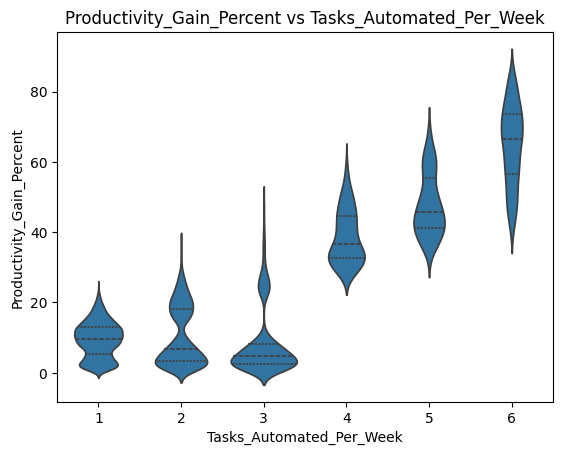

In [78]:
sns.violinplot(data=df,x='Tasks_Automated_Per_Week',y=trgt,inner="quartile")
plt.title(f"{trgt} vs Tasks_Automated_Per_Week")
plt.show()
print("\n")

In [ ]:
#Strip Plot = every data point as a dot — shows exact values, density, outliers, and group comparisons

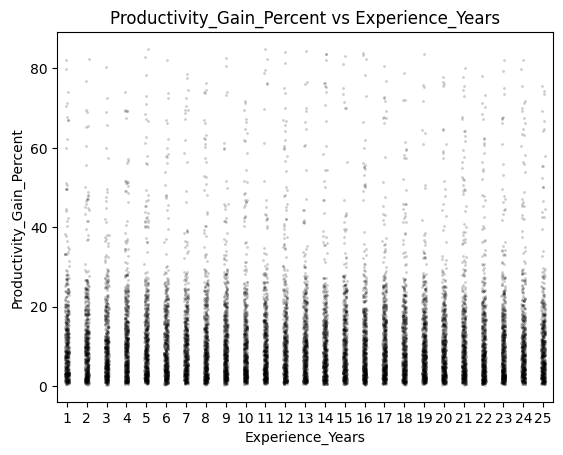

In [77]:
sns.stripplot(data=df,x='Experience_Years',y=trgt,color="black",alpha=0.2,jitter=True,size=2)
plt.title(f"{trgt} vs Experience_Years")
plt.show()
print("\n")

In [78]:
#productivity percentage of which job_roles increased

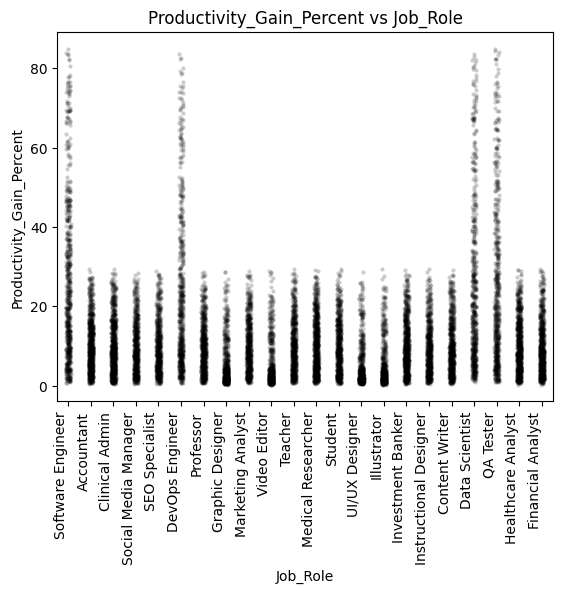

In [79]:
sns.stripplot(data=df,x='Job_Role',y=trgt,color="black",alpha=0.2,jitter=True,size=3)
plt.xticks(rotation=90,ha="right")
plt.title(f"{trgt} vs Job_Role")
plt.show()

# CORRELATION WITH TARGET

In [90]:
num_df=df.select_dtypes(include="number")
corr=num_df.corr(numeric_only=True)
corr_trgt=corr[trgt].drop(labels=[trgt]).sort_values(ascending=False)
print(corr_trgt)

Daily_Token_Usage           0.837869
Tasks_Automated_Per_Week    0.490684
month                       0.006202
dayofweek                   0.004746
year                       -0.006798
Experience_Years           -0.011696
day                        -0.018484
Name: Productivity_Gain_Percent, dtype: float64


# SPLITING DATASET

In [97]:
X=df.drop(columns=trgt)
y=df[trgt]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=None)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (12000, 11) | Test size: (3000, 11)


In [99]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Industry", "Job_Role", "Location", "Primary_AI_Tool"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,year,month,day,dayofweek
0,5,17,1,13,0,10640.0,2,19.3,2023,2,28,1
1,5,17,4,9,1,8535.0,1,5.0,2023,8,17,3
2,2,0,0,21,1,9585.0,1,13.4,2023,11,2,3
3,3,1,4,20,6,7094.0,2,9.9,2025,6,6,4
4,4,16,0,14,0,9277.0,1,12.8,2023,4,3,0


In [100]:
from xgboost import XGBRegressor


In [101]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({"Model": name, "R2 Score": round(r2, 4), "RMSE": round(rmse, 3), "MAE": round(mae, 3)})
    print(f"{name}: R2={r2:.4f} | RMSE={rmse:.3f} | MAE={mae:.3f}")

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
results_df

Random Forest: R2=0.8750 | RMSE=4.189 | MAE=2.845
Gradient Boosting: R2=0.8799 | RMSE=4.106 | MAE=2.835
XGBoost: R2=0.8718 | RMSE=4.242 | MAE=2.872


,Model,R2 Score,RMSE,MAE
1,Gradient Boosting,0.8799,4.106,2.835
0,Random Forest,0.8750,4.189,2.845
2,XGBoost,0.8718,4.242,2.872


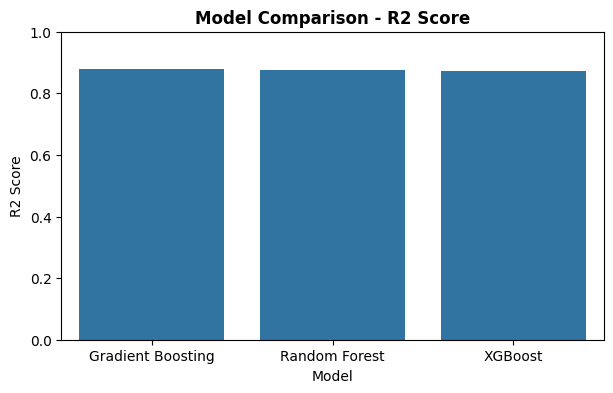

In [102]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison - R2 Score",fontweight='bold')
plt.ylim(0, 1)
plt.show()

In [103]:
 #Feature Importance (Best Model)


Best Model: Gradient Boosting


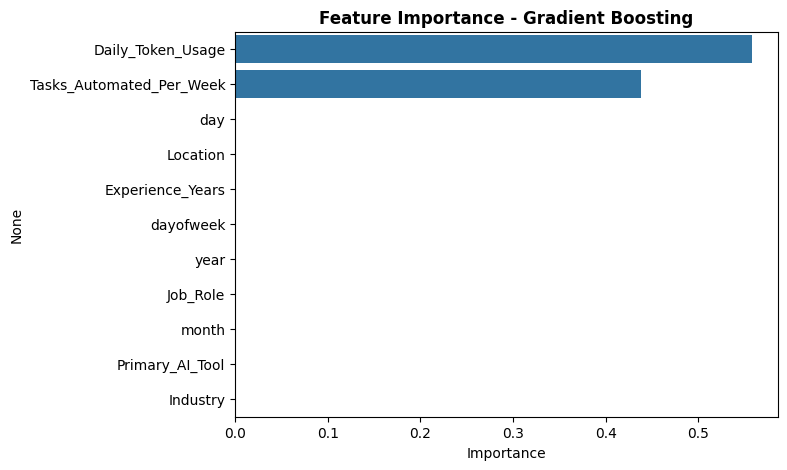

In [104]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model:", best_model_name)

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"Feature Importance - {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.show()

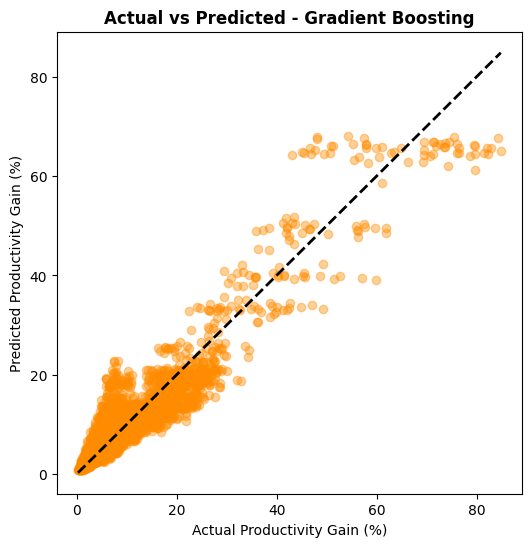

In [105]:
best_preds = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.4, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Productivity Gain (%)")
plt.ylabel("Predicted Productivity Gain (%)")
plt.title(f"Actual vs Predicted - {best_model_name}",fontweight='bold')
plt.show()


We built a model to predict Productivity Gain (%) from AI tool usage patterns across 15,000 users.
Daily_Token_Usage and Tasks_Automated_Per_Week turned out to be the strongest predictors of productivity gain — the more a user engages with AI tools, the higher their productivity boost.
Among the three models tested, the best performing model achieved the highest R² score (shown in the comparison table above), meaning it explains most of the variance in productivity gains.
Experience_Years had very little correlation with productivity gain, suggesting that how much you use AI matters more than how experienced you are.
Next steps: Try hyperparameter tuning (GridSearchCV), add interaction features (e.g., tool × industry), or test on newer adoption data to make predictions more robust

**ENCODING CATEGORYCAL COLS**

In [87]:
cat_cols=['Industry', 'Job_Role', 'Location','Primary_AI_Tool']

preprocess=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ],
    remainder="passthrough"
)

TRAINING PHASE

In [89]:
models={
    "decision tree":DecisionTreeRegressor(random_state=42),
    "random forest":RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1),
    "extra trees":ExtraTreesRegressor(n_estimators=300,random_state=42,n_jobs=-1),
    "gradient boosting":GradientBoostingRegressor(random_state=42),
    "ada boost":AdaBoostRegressor(random_state=42),
    "knn": KNeighborsRegressor(n_neighbors=10)

}

metrics={}

for name,model in models.items():
    pipe=Pipeline([
        ("prep",preprocess),
        ("model",model)
    ])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)

    metrics[name]={
        "mae":mean_absolute_error(y_test,pred),
        "rmse":mean_squared_error(y_test,pred),
        "r2":r2_score(y_test,pred)
    }
    print("\n")
    print("\n")

metrics

{'decision tree': {'mae': 3.7700333333333336,
  'rmse': 33.06715666666667,
  'r2': 0.7643633764598083},
 'random forest': {'mae': 2.830865333333334,
  'rmse': 17.374314981925927,
  'r2': 0.8761905972160052},
 'extra trees': {'mae': 2.876916666666667,
  'rmse': 18.324398159925927,
  'r2': 0.8694203026181654},
 'gradient boosting': {'mae': 2.8390414455547974,
  'rmse': 16.81536788988486,
  'r2': 0.8801736552948672},
 'ada boost': {'mae': 3.334715660506167,
  'rmse': 19.68415654039278,
  'r2': 0.8597306617205954},
 'knn': {'mae': 3.501993333333333,
  'rmse': 29.4831552,
  'r2': 0.7899029779708069}}